EXPLORATORY DATA ANALYSIS - STREAMFLOW DATA

TASK 1: Load and Inspect Data

DATA CLEANING

Cleaning headwater data (Bear River)...
  Outlier threshold: 3357.39 cfs

Cleaning reservoir data (Ogden below Pineview)...
  Outlier threshold: 2354.02 cfs

Cleaning terminus data (Jordan River)...
  Outlier threshold: 5683.22 cfs

CLEANING SUMMARY
Headwater - Shape: (12418, 1), NaN count: 3032
Reservoir - Shape: (10957, 1), NaN count: 608
Terminus - Shape: 929

Date ranges:
Headwater: 1986-10-01 00:00:00 to 2020-09-29 00:00:00
Reservoir: 1990-10-01 00:00:00 to 2020-09-29 00:00:00
Terminus: 1986-10-01 00:00:00 to 2020-09-29 00:00:00

Headwater sample:
            USGS_flow
Datetime             
1986-10-01  89.176470
1986-10-02  95.166664
1986-10-03  99.250000
1986-10-04  90.958336
1986-10-05  91.000000
1986-10-06  90.625000
1986-10-07  91.250000
1986-10-08  91.958336
1986-10-09  92.875000
1986-10-10  91.583336

TASK 2: Slice Data for 6-Year Overlapping Period

Data for 2000-2005:
Headwater: 2192

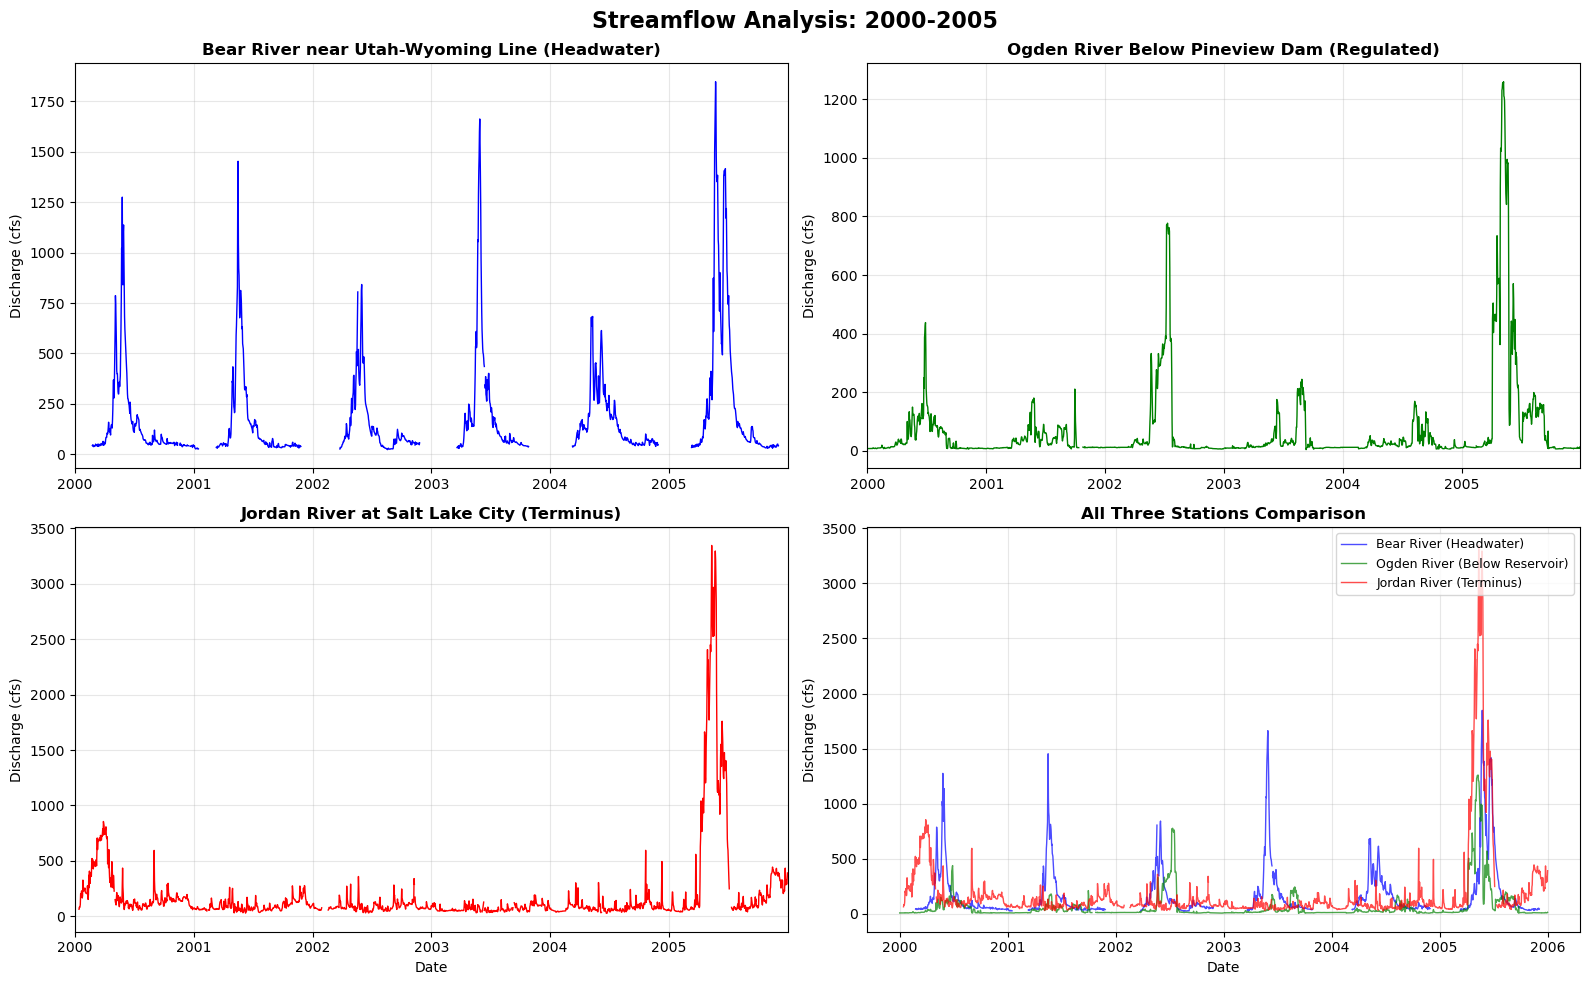


TASK 4: Merge DataFrames

All_Streams DataFrame:
            Bear_River_Headwater  Ogden_Below_Pineview  Jordan_River_Terminus
Datetime                                                                     
2000-01-01                   NaN              7.800000                    NaN
2000-01-02                   NaN              7.800000                    NaN
2000-01-03                   NaN              7.918750                    NaN
2000-01-04                   NaN              7.956250                    NaN
2000-01-05                   NaN              8.081250                    NaN
2000-01-06                   NaN              7.846875                    NaN
2000-01-07                   NaN              7.687500                    NaN
2000-01-08                   NaN              7.800000                    NaN
2000-01-09                   NaN              7.831250                    NaN
2000-01-10                   NaN              7.802084                    NaN
2000-01-11    

/scratch/local/u0760447/880653/ipykernel_2693785/3469338263.py:210: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  All_Streams_Monthly = All_Streams.resample('M').sum() * 86400 / 43560


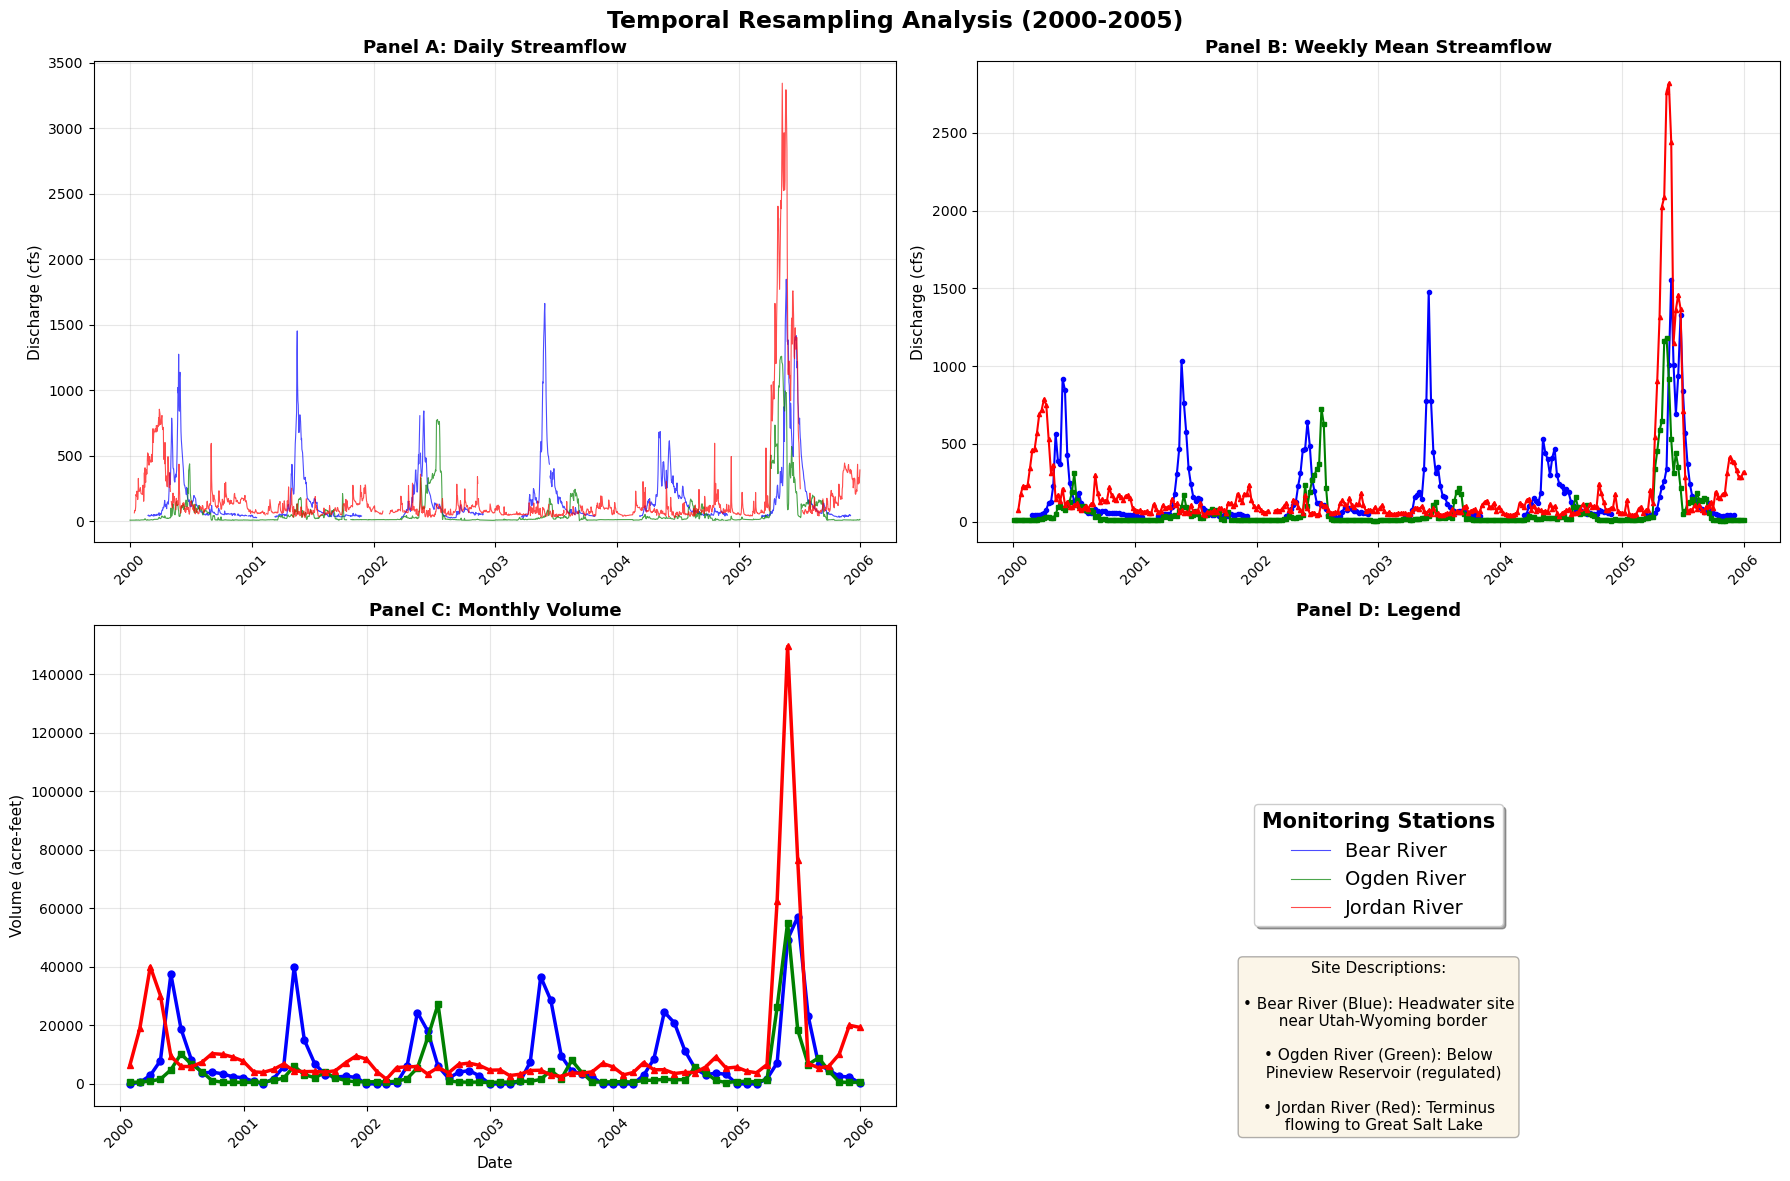


TEMPORAL RESAMPLING - COMPARISON ANALYSIS

How temporal resampling highlights differences:

1. TIMING:
   Daily - Bear River peak: 2005-05-24
   Daily - Ogden River peak: 2005-05-10
   Monthly - Bear River peak: 2005-06
   Monthly - Ogden River peak: 2005-05

2. MAGNITUDE:
   Bear River - Mean daily: 183.5 cfs
   Bear River - Mean weekly: 178.7 cfs
   Bear River - Total monthly volume: 571469 acre-ft

3. VARIABILITY:
   Bear River - Daily std: 261.3 cfs
   Bear River - Weekly std: 249.9 cfs
   Ogden River - Daily std: 148.7 cfs (regulated - lower variability)

4. KEY OBSERVATIONS:
   • Weekly aggregation smooths daily fluctuations
   • Monthly volumes show seasonal patterns more clearly
   • Regulated flow (Ogden) shows less daily variability than natural flow (Bear)
   • Snowmelt pulse timing visible in all temporal scales

WET vs DRY YEAR COMPARATIVE ANALYSIS

Annual Total Volumes (acre-feet):
            Bear_River_Headwater  Ogden_Below_Pineview  Jordan_River_Terminus
Datetime    

/scratch/local/u0760447/880653/ipykernel_2693785/3469338263.py:326: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  annual_totals = All_Streams_Monthly.resample('Y').sum()


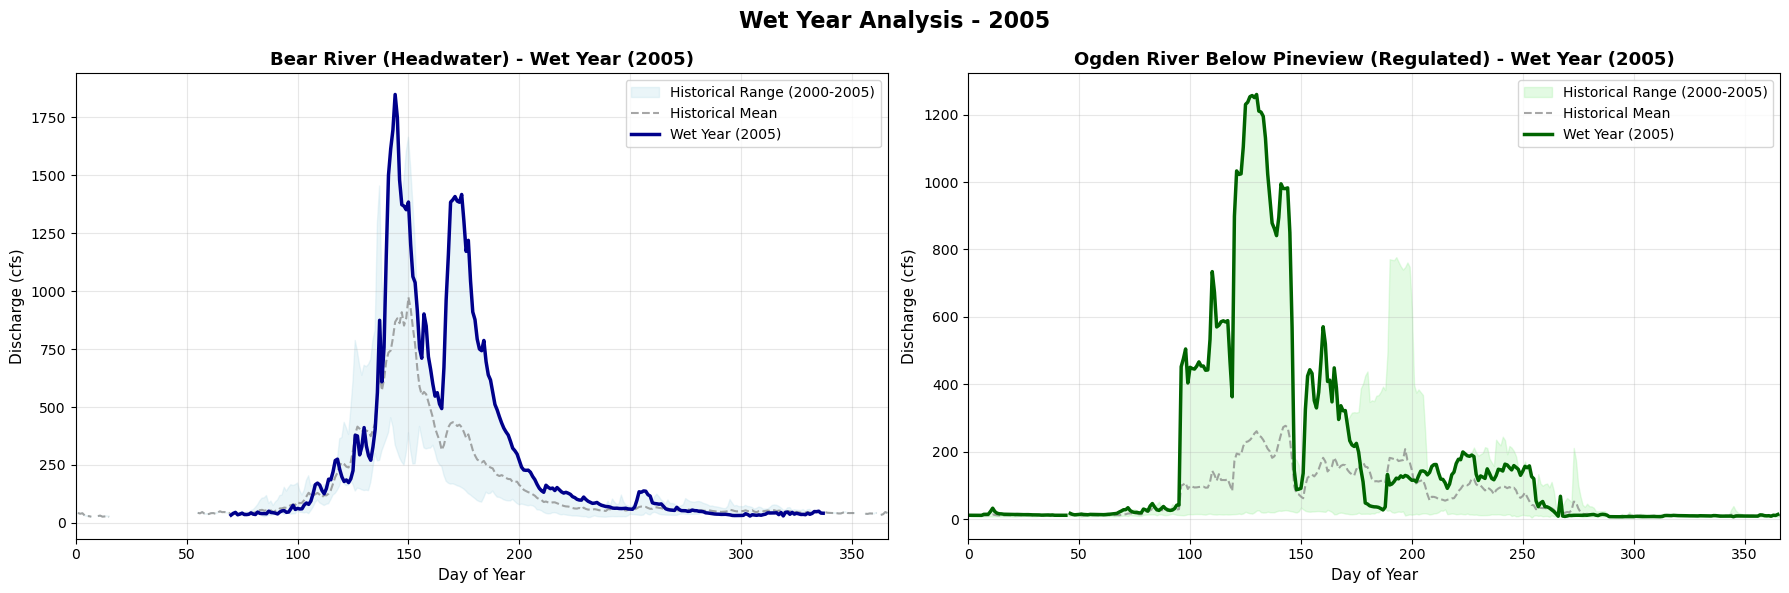


Creating dry year visualization...


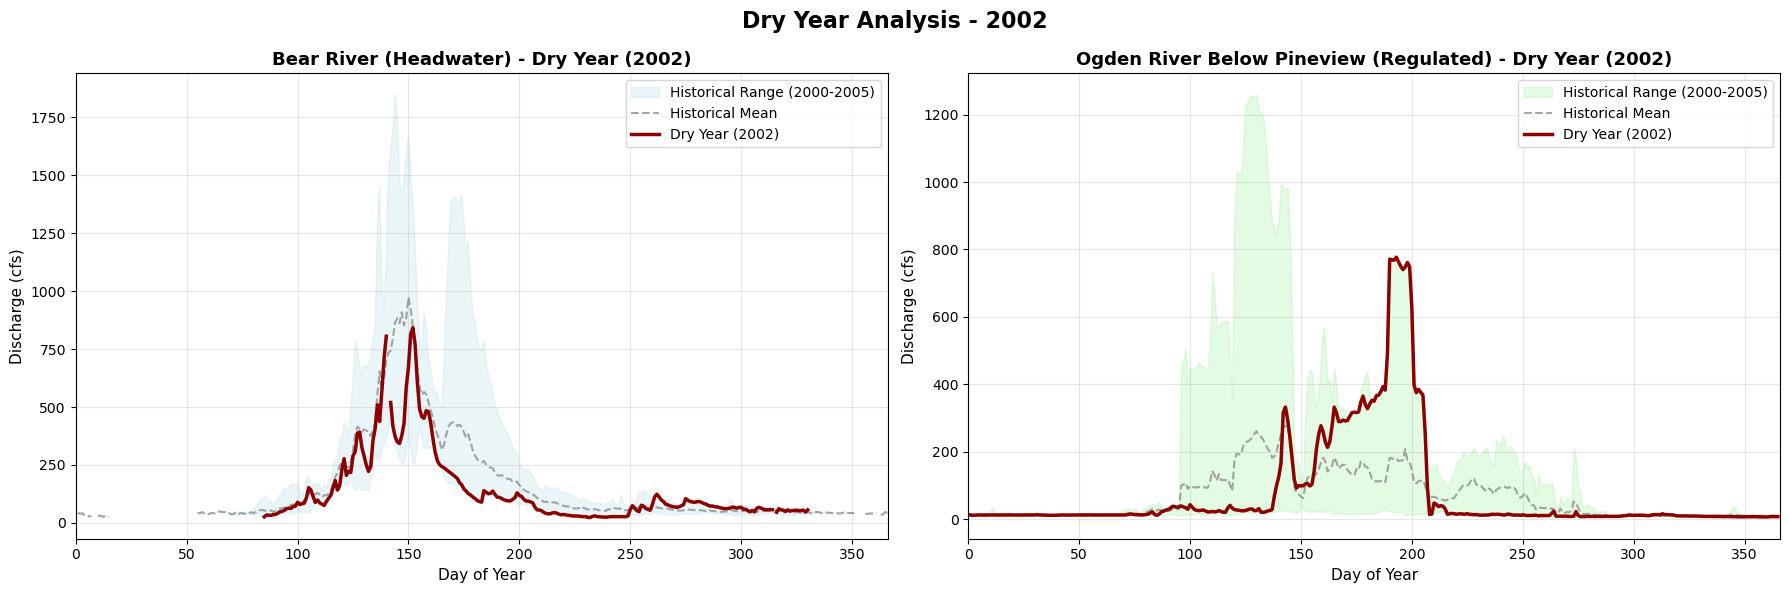


ENGINEERING INTERPRETATION

WET YEAR (2005) - Peak Flow Timing:
  Bear River (Headwater):      May 24 (DOY 144)
  Ogden River (Below Reservoir): May 10 (DOY 130)
  Peak magnitude - Bear:   1847.6 cfs
  Peak magnitude - Ogden:  1259.8 cfs

DRY YEAR (2002) - Peak Flow Timing:
  Bear River (Headwater):      June 01 (DOY 152)
  Ogden River (Below Reservoir): July 12 (DOY 193)
  Peak magnitude - Bear:   842.0 cfs
  Peak magnitude - Ogden:  777.0 cfs

KEY FINDINGS:
  • Natural headwater (Bear River) shows strong seasonal snowmelt pulse
  • Regulated flow (Ogden below Pineview) shows dampened peaks due to reservoir operations
  • Wet year peaks are 2.2x higher than dry year for Bear River
  • Reservoir operations moderate flow variations between wet and dry years

ANALYSIS COMPLETE!


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

print("EXPLORATORY DATA ANALYSIS - STREAMFLOW DATA")

# Load and Inspect Data

print("\nTASK 1: Load and Inspect Data")


# Define file paths (adjust these to your actual site IDs and file names)

headwater_site = "~/Hydroinformatics/Hydroinformatics-2026/Data/NWIS_Streamflow/Utah/10011500_1980_2020.csv"
reservoir_site = "~/Hydroinformatics/Hydroinformatics-2026/Data/NWIS_Streamflow/Utah/10140100_1980_2020.csv"
terminus_site = "~/Hydroinformatics/Hydroinformatics-2026/Data/NWIS_Streamflow/Utah/10141000_1980_2020.csv"


# DATA CLEANING

print("DATA CLEANING")


def clean_usgs_data(df):
    """
    Clean USGS streamflow data
    """
    # Make a copy
    df_clean = df.copy()
    
    # Check if columns exist
    if 'Datetime' not in df_clean.columns or 'USGS_flow' not in df_clean.columns:
        print(f"ERROR: Expected columns not found. Available: {df_clean.columns.tolist()}")
        return None
    
    # Convert date to datetime
    df_clean['Datetime'] = pd.to_datetime(df_clean['Datetime'], errors='coerce')
    
    # Convert discharge to numeric
    df_clean['USGS_flow'] = pd.to_numeric(df_clean['USGS_flow'], errors='coerce')
    
    # Replace -999 and negative values with NaN
    df_clean.loc[df_clean['USGS_flow'] < 0, 'USGS_flow'] = np.nan
    df_clean.loc[df_clean['USGS_flow'] == -999, 'USGS_flow'] = np.nan
    
    # Remove extreme outliers (values > 99th percentile * 2)
    upper_limit = df_clean['USGS_flow'].quantile(0.99) * 2
    print(f"  Outlier threshold: {upper_limit:.2f} cfs")
    df_clean.loc[df_clean['USGS_flow'] > upper_limit, 'USGS_flow'] = np.nan
    
    # Set date as index
    df_clean = df_clean.set_index('Datetime')
    
    # Keep only the discharge column
    df_clean = df_clean[['USGS_flow']]
    
    return df_clean

# Clean all dataframes
print("\nCleaning headwater data (Bear River)...")
headwater_clean = clean_usgs_data(headwater_df)

print("\nCleaning reservoir data (Ogden below Pineview)...")
reservoir_clean = clean_usgs_data(reservoir_df)

print("\nCleaning terminus data (Jordan River)...")
terminus_clean = clean_usgs_data(terminus_df)

# Check cleaning results
print("\n" + "=" * 70)
print("CLEANING SUMMARY")
print("=" * 70)
print(f"Headwater - Shape: {headwater_clean.shape}, NaN count: {headwater_clean.isna().sum().sum()}")
print(f"Reservoir - Shape: {reservoir_clean.shape}, NaN count: {reservoir_clean.isna().sum().sum()}")
print(f"Terminus - Shape: {terminus_clean.isna().sum().sum()}")

print("\nDate ranges:")
print(f"Headwater: {headwater_clean.index.min()} to {headwater_clean.index.max()}")
print(f"Reservoir: {reservoir_clean.index.min()} to {reservoir_clean.index.max()}")
print(f"Terminus: {terminus_clean.index.min()} to {terminus_clean.index.max()}")

print("\nHeadwater sample:")
print(headwater_clean.head(10))

# ========================================================================
# TASK 2: Slice Data (6 years overlapping)
# ========================================================================
print("\n" + "=" * 70)
print("TASK 2: Slice Data for 6-Year Overlapping Period")
print("=" * 70)

# Find overlapping period - use 2000-2005 (6 years)
start_year = '2000'
end_year = '2005'

headwater_6yr = headwater_clean[start_year:end_year]
reservoir_6yr = reservoir_clean[start_year:end_year]
terminus_6yr = terminus_clean[start_year:end_year]

print(f"\nData for {start_year}-{end_year}:")
print(f"Headwater: {len(headwater_6yr)} records")
print(f"Reservoir: {len(reservoir_6yr)} records")
print(f"Terminus: {len(terminus_6yr)} records")

# ========================================================================
# TASK 3: Initial Visualization (4 subplots)
# ========================================================================
print("\n" + "=" * 70)
print("TASK 3: Creating Four-Panel Visualization")
print("=" * 70)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Panel 1: Headwater (Bear River)
axes[0, 0].plot(headwater_6yr.index, headwater_6yr['USGS_flow'], 
                color='blue', linewidth=1)
axes[0, 0].set_title('Bear River near Utah-Wyoming Line (Headwater)', 
                      fontweight='bold', fontsize=12)
axes[0, 0].set_ylabel('Discharge (cfs)', fontsize=10)
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].set_xlim(headwater_6yr.index.min(), headwater_6yr.index.max())

# Panel 2: Below Reservoir (Ogden River)
axes[0, 1].plot(reservoir_6yr.index, reservoir_6yr['USGS_flow'], 
                color='green', linewidth=1)
axes[0, 1].set_title('Ogden River Below Pineview Dam (Regulated)', 
                      fontweight='bold', fontsize=12)
axes[0, 1].set_ylabel('Discharge (cfs)', fontsize=10)
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].set_xlim(reservoir_6yr.index.min(), reservoir_6yr.index.max())

# Panel 3: Terminus (Jordan River)
axes[1, 0].plot(terminus_6yr.index, terminus_6yr['USGS_flow'], 
                color='red', linewidth=1)
axes[1, 0].set_title('Jordan River at Salt Lake City (Terminus)', 
                      fontweight='bold', fontsize=12)
axes[1, 0].set_xlabel('Date', fontsize=10)
axes[1, 0].set_ylabel('Discharge (cfs)', fontsize=10)
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].set_xlim(terminus_6yr.index.min(), terminus_6yr.index.max())

# Panel 4: All three streams together
axes[1, 1].plot(headwater_6yr.index, headwater_6yr['USGS_flow'], 
                label='Bear River (Headwater)', color='blue', alpha=0.7, linewidth=1)
axes[1, 1].plot(reservoir_6yr.index, reservoir_6yr['USGS_flow'], 
                label='Ogden River (Below Reservoir)', color='green', alpha=0.7, linewidth=1)
axes[1, 1].plot(terminus_6yr.index, terminus_6yr['USGS_flow'], 
                label='Jordan River (Terminus)', color='red', alpha=0.7, linewidth=1)
axes[1, 1].set_title('All Three Stations Comparison', 
                      fontweight='bold', fontsize=12)
axes[1, 1].set_xlabel('Date', fontsize=10)
axes[1, 1].set_ylabel('Discharge (cfs)', fontsize=10)
axes[1, 1].legend(loc='upper right', fontsize=9)
axes[1, 1].grid(True, alpha=0.3)

fig.suptitle('Streamflow Analysis: 2000-2005', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# ========================================================================
# TASK 4: Create Combined DataFrame
# ========================================================================
print("\n" + "=" * 70)
print("TASK 4: Merge DataFrames")
print("=" * 70)

# Create All_Streams with custom labels
All_Streams = pd.DataFrame({
    'Bear_River_Headwater': headwater_6yr['USGS_flow'],
    'Ogden_Below_Pineview': reservoir_6yr['USGS_flow'],
    'Jordan_River_Terminus': terminus_6yr['USGS_flow']
})

print("\nAll_Streams DataFrame:")
print(All_Streams.head(20))
print(f"\nShape: {All_Streams.shape}")
print(f"Date range: {All_Streams.index.min()} to {All_Streams.index.max()}")

print("\nSummary Statistics:")
print(All_Streams.describe())

print("\n" + "=" * 70)
print("COMPARISON ANALYSIS")
print("=" * 70)
print("\nTiming of peak flows:")
print(f"Bear River peak: {All_Streams['Bear_River_Headwater'].idxmax().strftime('%Y-%m-%d')}")
print(f"Ogden River peak: {All_Streams['Ogden_Below_Pineview'].idxmax().strftime('%Y-%m-%d')}")
print(f"Jordan River peak: {All_Streams['Jordan_River_Terminus'].idxmax().strftime('%Y-%m-%d')}")

print("\nMagnitude (mean discharge):")
print(f"Bear River: {All_Streams['Bear_River_Headwater'].mean():.1f} cfs")
print(f"Ogden River: {All_Streams['Ogden_Below_Pineview'].mean():.1f} cfs")
print(f"Jordan River: {All_Streams['Jordan_River_Terminus'].mean():.1f} cfs")

# ========================================================================
# TEMPORAL RESAMPLING (Assignment Task 3)
# ========================================================================
print("\n" + "=" * 70)
print("TEMPORAL RESAMPLING & STATISTICAL AGGREGATION")
print("=" * 70)

# Resample to Weekly Mean
All_Streams_Weekly = All_Streams.resample('W').mean()

# Resample to Monthly Total (convert cfs to volumetric)
# cfs * 86400 seconds/day * days_in_month = cubic feet per month
# Divide by 43560 to convert to acre-feet
All_Streams_Monthly = All_Streams.resample('M').sum() * 86400 / 43560

print(f"\nDaily data points: {len(All_Streams)}")
print(f"Weekly data points: {len(All_Streams_Weekly)}")
print(f"Monthly data points: {len(All_Streams_Monthly)}")

print("\nMonthly Volume Statistics (acre-feet):")
print(All_Streams_Monthly.describe())

# -------------------------------------------------------------------------
# FIGURE: Multi-panel comparison (Daily, Weekly, Monthly) + Legend
# -------------------------------------------------------------------------
print("\nCreating temporal resampling visualization...")

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# Panel A: Daily (Raw)
axes[0, 0].plot(All_Streams.index, All_Streams['Bear_River_Headwater'], 
                label='Bear River', color='blue', linewidth=0.8, alpha=0.7)
axes[0, 0].plot(All_Streams.index, All_Streams['Ogden_Below_Pineview'], 
                label='Ogden River', color='green', linewidth=0.8, alpha=0.7)
axes[0, 0].plot(All_Streams.index, All_Streams['Jordan_River_Terminus'], 
                label='Jordan River', color='red', linewidth=0.8, alpha=0.7)
axes[0, 0].set_title('Panel A: Daily Streamflow', fontweight='bold', fontsize=13)
axes[0, 0].set_ylabel('Discharge (cfs)', fontsize=11)
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].tick_params(axis='x', rotation=45)

# Panel B: Weekly Mean
axes[0, 1].plot(All_Streams_Weekly.index, All_Streams_Weekly['Bear_River_Headwater'], 
                label='Bear River', color='blue', linewidth=1.5, marker='o', markersize=3)
axes[0, 1].plot(All_Streams_Weekly.index, All_Streams_Weekly['Ogden_Below_Pineview'], 
                label='Ogden River', color='green', linewidth=1.5, marker='s', markersize=3)
axes[0, 1].plot(All_Streams_Weekly.index, All_Streams_Weekly['Jordan_River_Terminus'], 
                label='Jordan River', color='red', linewidth=1.5, marker='^', markersize=3)
axes[0, 1].set_title('Panel B: Weekly Mean Streamflow', fontweight='bold', fontsize=13)
axes[0, 1].set_ylabel('Discharge (cfs)', fontsize=11)
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].tick_params(axis='x', rotation=45)

# Panel C: Monthly Volume
axes[1, 0].plot(All_Streams_Monthly.index, All_Streams_Monthly['Bear_River_Headwater'], 
                label='Bear River', color='blue', linewidth=2.5, marker='o', markersize=5)
axes[1, 0].plot(All_Streams_Monthly.index, All_Streams_Monthly['Ogden_Below_Pineview'], 
                label='Ogden River', color='green', linewidth=2.5, marker='s', markersize=5)
axes[1, 0].plot(All_Streams_Monthly.index, All_Streams_Monthly['Jordan_River_Terminus'], 
                label='Jordan River', color='red', linewidth=2.5, marker='^', markersize=5)
axes[1, 0].set_title('Panel C: Monthly Volume', fontweight='bold', fontsize=13)
axes[1, 0].set_xlabel('Date', fontsize=11)
axes[1, 0].set_ylabel('Volume (acre-feet)', fontsize=11)
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].tick_params(axis='x', rotation=45)

# Panel D: Legend Only
axes[1, 1].axis('off')
handles, labels = axes[0, 0].get_legend_handles_labels()
legend = axes[1, 1].legend(handles, labels, loc='center', fontsize=14, 
                           frameon=True, shadow=True, title='Monitoring Stations')
legend.get_title().set_fontsize(15)
legend.get_title().set_fontweight('bold')
axes[1, 1].set_title('Panel D: Legend', fontweight='bold', fontsize=13)

# Add text description in Panel D
description = (
    "Site Descriptions:\n\n"
    "• Bear River (Blue): Headwater site\n"
    "  near Utah-Wyoming border\n\n"
    "• Ogden River (Green): Below\n"
    "  Pineview Reservoir (regulated)\n\n"
    "• Jordan River (Red): Terminus\n"
    "  flowing to Great Salt Lake"
)
axes[1, 1].text(0.5, 0.3, description, 
                ha='center', va='top', fontsize=11,
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))

fig.suptitle('Temporal Resampling Analysis (2000-2005)', 
             fontsize=17, fontweight='bold')
plt.tight_layout()
plt.show()

# Compare and Contrast Analysis
print("\n" + "=" * 70)
print("TEMPORAL RESAMPLING - COMPARISON ANALYSIS")
print("=" * 70)

print("\nHow temporal resampling highlights differences:")
print("\n1. TIMING:")
print(f"   Daily - Bear River peak: {All_Streams['Bear_River_Headwater'].idxmax().strftime('%Y-%m-%d')}")
print(f"   Daily - Ogden River peak: {All_Streams['Ogden_Below_Pineview'].idxmax().strftime('%Y-%m-%d')}")
print(f"   Monthly - Bear River peak: {All_Streams_Monthly['Bear_River_Headwater'].idxmax().strftime('%Y-%m')}")
print(f"   Monthly - Ogden River peak: {All_Streams_Monthly['Ogden_Below_Pineview'].idxmax().strftime('%Y-%m')}")

print("\n2. MAGNITUDE:")
print(f"   Bear River - Mean daily: {All_Streams['Bear_River_Headwater'].mean():.1f} cfs")
print(f"   Bear River - Mean weekly: {All_Streams_Weekly['Bear_River_Headwater'].mean():.1f} cfs")
print(f"   Bear River - Total monthly volume: {All_Streams_Monthly['Bear_River_Headwater'].sum():.0f} acre-ft")

print("\n3. VARIABILITY:")
print(f"   Bear River - Daily std: {All_Streams['Bear_River_Headwater'].std():.1f} cfs")
print(f"   Bear River - Weekly std: {All_Streams_Weekly['Bear_River_Headwater'].std():.1f} cfs")
print(f"   Ogden River - Daily std: {All_Streams['Ogden_Below_Pineview'].std():.1f} cfs (regulated - lower variability)")

print("\n4. KEY OBSERVATIONS:")
print("   • Weekly aggregation smooths daily fluctuations")
print("   • Monthly volumes show seasonal patterns more clearly")
print("   • Regulated flow (Ogden) shows less daily variability than natural flow (Bear)")
print("   • Snowmelt pulse timing visible in all temporal scales")
# ========================================================================
# WET vs DRY YEAR COMPARATIVE ANALYSIS (Assignment Task 4)
# ========================================================================
print("\n" + "=" * 70)
print("WET vs DRY YEAR COMPARATIVE ANALYSIS")
print("=" * 70)

# Identify wet and dry years based on annual total volume
annual_totals = All_Streams_Monthly.resample('Y').sum()

print("\nAnnual Total Volumes (acre-feet):")
print(annual_totals)

# Find wet and dry years for HEADWATER (Bear River)
wet_year_headwater = annual_totals['Bear_River_Headwater'].idxmax().year
dry_year_headwater = annual_totals['Bear_River_Headwater'].idxmin().year

# Find wet and dry years for RESERVOIR (Ogden River)
wet_year_reservoir = annual_totals['Ogden_Below_Pineview'].idxmax().year
dry_year_reservoir = annual_totals['Ogden_Below_Pineview'].idxmin().year

print(f"\nWet year (Bear River - Headwater): {wet_year_headwater}")
print(f"Dry year (Bear River - Headwater): {dry_year_headwater}")
print(f"Wet year (Ogden River - Below Reservoir): {wet_year_reservoir}")
print(f"Dry year (Ogden River - Below Reservoir): {dry_year_reservoir}")

# Use a common wet/dry year for comparison (use Bear River as reference)
wet_year = wet_year_headwater
dry_year = dry_year_headwater

print(f"\n>>> Using {wet_year} as WET year and {dry_year} as DRY year for analysis")

# Extract data for wet and dry years
wet_data_headwater = All_Streams[All_Streams.index.year == wet_year]['Bear_River_Headwater']
dry_data_headwater = All_Streams[All_Streams.index.year == dry_year]['Bear_River_Headwater']

wet_data_reservoir = All_Streams[All_Streams.index.year == wet_year]['Ogden_Below_Pineview']
dry_data_reservoir = All_Streams[All_Streams.index.year == dry_year]['Ogden_Below_Pineview']

# Calculate historical range (min/max for each day of year) - ALL years
All_Streams_doy = All_Streams.copy()
All_Streams_doy['dayofyear'] = All_Streams_doy.index.dayofyear

daily_stats_headwater = All_Streams_doy.groupby('dayofyear')['Bear_River_Headwater'].agg(['min', 'max', 'mean'])
daily_stats_reservoir = All_Streams_doy.groupby('dayofyear')['Ogden_Below_Pineview'].agg(['min', 'max', 'mean'])

# -------------------------------------------------------------------------
# FIGURE: Wet Year Comparison (Headwater vs Reservoir)
# -------------------------------------------------------------------------
print("\nCreating wet year visualization...")

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Wet Year - Headwater (Bear River)
wet_doy_headwater = wet_data_headwater.index.dayofyear

axes[0].fill_between(daily_stats_headwater.index, 
                      daily_stats_headwater['min'], 
                      daily_stats_headwater['max'],
                      alpha=0.25, color='lightblue', label='Historical Range (2000-2005)')
axes[0].plot(daily_stats_headwater.index, daily_stats_headwater['mean'],
             color='gray', linewidth=1.5, linestyle='--', alpha=0.7, label='Historical Mean')
axes[0].plot(wet_doy_headwater, wet_data_headwater.values,
             color='darkblue', linewidth=2.5, label=f'Wet Year ({wet_year})')
axes[0].set_title(f'Bear River (Headwater) - Wet Year ({wet_year})', 
                  fontweight='bold', fontsize=13)
axes[0].set_xlabel('Day of Year', fontsize=11)
axes[0].set_ylabel('Discharge (cfs)', fontsize=11)
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)
axes[0].set_xlim(0, 366)

# Wet Year - Below Reservoir (Ogden River)
wet_doy_reservoir = wet_data_reservoir.index.dayofyear

axes[1].fill_between(daily_stats_reservoir.index, 
                      daily_stats_reservoir['min'], 
                      daily_stats_reservoir['max'],
                      alpha=0.25, color='lightgreen', label='Historical Range (2000-2005)')
axes[1].plot(daily_stats_reservoir.index, daily_stats_reservoir['mean'],
             color='gray', linewidth=1.5, linestyle='--', alpha=0.7, label='Historical Mean')
axes[1].plot(wet_doy_reservoir, wet_data_reservoir.values,
             color='darkgreen', linewidth=2.5, label=f'Wet Year ({wet_year})')
axes[1].set_title(f'Ogden River Below Pineview (Regulated) - Wet Year ({wet_year})', 
                  fontweight='bold', fontsize=13)
axes[1].set_xlabel('Day of Year', fontsize=11)
axes[1].set_ylabel('Discharge (cfs)', fontsize=11)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)
axes[1].set_xlim(0, 366)

fig.suptitle(f'Wet Year Analysis - {wet_year}', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# -------------------------------------------------------------------------
# FIGURE: Dry Year Comparison (Headwater vs Reservoir)
# -------------------------------------------------------------------------
print("\nCreating dry year visualization...")

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Dry Year - Headwater (Bear River)
dry_doy_headwater = dry_data_headwater.index.dayofyear

axes[0].fill_between(daily_stats_headwater.index, 
                      daily_stats_headwater['min'], 
                      daily_stats_headwater['max'],
                      alpha=0.25, color='lightblue', label='Historical Range (2000-2005)')
axes[0].plot(daily_stats_headwater.index, daily_stats_headwater['mean'],
             color='gray', linewidth=1.5, linestyle='--', alpha=0.7, label='Historical Mean')
axes[0].plot(dry_doy_headwater, dry_data_headwater.values,
             color='darkred', linewidth=2.5, label=f'Dry Year ({dry_year})')
axes[0].set_title(f'Bear River (Headwater) - Dry Year ({dry_year})', 
                  fontweight='bold', fontsize=13)
axes[0].set_xlabel('Day of Year', fontsize=11)
axes[0].set_ylabel('Discharge (cfs)', fontsize=11)
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)
axes[0].set_xlim(0, 366)

# Dry Year - Below Reservoir (Ogden River)
dry_doy_reservoir = dry_data_reservoir.index.dayofyear

axes[1].fill_between(daily_stats_reservoir.index, 
                      daily_stats_reservoir['min'], 
                      daily_stats_reservoir['max'],
                      alpha=0.25, color='lightgreen', label='Historical Range (2000-2005)')
axes[1].plot(daily_stats_reservoir.index, daily_stats_reservoir['mean'],
             color='gray', linewidth=1.5, linestyle='--', alpha=0.7, label='Historical Mean')
axes[1].plot(dry_doy_reservoir, dry_data_reservoir.values,
             color='darkred', linewidth=2.5, label=f'Dry Year ({dry_year})')
axes[1].set_title(f'Ogden River Below Pineview (Regulated) - Dry Year ({dry_year})', 
                  fontweight='bold', fontsize=13)
axes[1].set_xlabel('Day of Year', fontsize=11)
axes[1].set_ylabel('Discharge (cfs)', fontsize=11)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)
axes[1].set_xlim(0, 366)

fig.suptitle(f'Dry Year Analysis - {dry_year}', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# -------------------------------------------------------------------------
# ENGINEERING INTERPRETATION
# -------------------------------------------------------------------------
print("\n" + "=" * 70)
print("ENGINEERING INTERPRETATION")
print("=" * 70)

# Peak timing analysis
headwater_wet_peak_date = wet_data_headwater.idxmax()
reservoir_wet_peak_date = wet_data_reservoir.idxmax()
headwater_dry_peak_date = dry_data_headwater.idxmax()
reservoir_dry_peak_date = dry_data_reservoir.idxmax()

print(f"\nWET YEAR ({wet_year}) - Peak Flow Timing:")
print(f"  Bear River (Headwater):      {headwater_wet_peak_date.strftime('%B %d')} (DOY {headwater_wet_peak_date.dayofyear})")
print(f"  Ogden River (Below Reservoir): {reservoir_wet_peak_date.strftime('%B %d')} (DOY {reservoir_wet_peak_date.dayofyear})")
print(f"  Peak magnitude - Bear:   {wet_data_headwater.max():.1f} cfs")
print(f"  Peak magnitude - Ogden:  {wet_data_reservoir.max():.1f} cfs")

print(f"\nDRY YEAR ({dry_year}) - Peak Flow Timing:")
print(f"  Bear River (Headwater):      {headwater_dry_peak_date.strftime('%B %d')} (DOY {headwater_dry_peak_date.dayofyear})")
print(f"  Ogden River (Below Reservoir): {reservoir_dry_peak_date.strftime('%B %d')} (DOY {reservoir_dry_peak_date.dayofyear})")
print(f"  Peak magnitude - Bear:   {dry_data_headwater.max():.1f} cfs")
print(f"  Peak magnitude - Ogden:  {dry_data_reservoir.max():.1f} cfs")

print(f"\nKEY FINDINGS:")
print(f"  • Natural headwater (Bear River) shows strong seasonal snowmelt pulse")
print(f"  • Regulated flow (Ogden below Pineview) shows dampened peaks due to reservoir operations")
print(f"  • Wet year peaks are {wet_data_headwater.max() / dry_data_headwater.max():.1f}x higher than dry year for Bear River")
print(f"  • Reservoir operations moderate flow variations between wet and dry years")

print("\n" + "=" * 70)
print("ANALYSIS COMPLETE!")
print("=" * 70)